<a href="https://colab.research.google.com/github/samanthaalves26/entrega_projeto_integrador/blob/main/Projeto_integrador_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import pandas as pd

# montar o Google Drive
drive.mount('/content/drive')

# pasta onde estão os arquivos CSV
pasta_csv = "/content/drive/MyDrive/Colab Notebooks/projeto integrador /"

# lista com os nomes dos arquivos (sem .csv)
arquivos = [
    "pedidos",
    "produtos",
    "tabela_auxiliar",
    "vendedores",
    "geolocalizacao",
    "itens_pedidos",
    "pagamentos",
    "avaliacoes",
    "clientes"
]

# dicionário para armazenar os DataFrames
df = {}

# loop para ler os arquivos
for nome in arquivos:

    # agora usando a pasta correta
    caminho = f"{pasta_csv}{nome}.csv"

    df[nome] = pd.read_csv(caminho, encoding="utf-8")

    print(f"{nome} carregado com sucesso!")

# exemplo
display(df["clientes"].head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pedidos carregado com sucesso!
produtos carregado com sucesso!
tabela_auxiliar carregado com sucesso!
vendedores carregado com sucesso!
geolocalizacao carregado com sucesso!
itens_pedidos carregado com sucesso!
pagamentos carregado com sucesso!
avaliacoes carregado com sucesso!
clientes carregado com sucesso!


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


# Etapa 1 — Tipagem e Padronização dos Dados

In [ ]:
colunas_data = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in colunas_data:
    df["pedidos"][col] = pd.to_datetime(df["pedidos"][col])

df["pedidos"]['order_status'] = df["pedidos"]['order_status'].astype('category')


# IDs como string
df["pedidos"]['order_id'] = df["pedidos"]['order_id'].astype('string')
df["pedidos"]['customer_id'] = df["pedidos"]['customer_id'].astype('string')


In [ ]:
def tratar_clientes(df):
    df['customer_zip_code_prefix'] = df['customer_zip_code_prefix'].astype(str)
    df['customer_city'] = df['customer_city'].astype('category')
    df['customer_state'] = df['customer_state'].astype('category')
    return df

df["clientes"] = tratar_clientes(df["clientes"])


# IDs como string
df["clientes"]['customer_id'] = (
    df["clientes"]['customer_id']
    .astype('string')
)

df["clientes"]['customer_unique_id'] = (
    df["clientes"]['customer_unique_id']
    .astype('string')
)

# CEP como string
df["clientes"]['customer_zip_code_prefix'] = (
    df["clientes"]['customer_zip_code_prefix']
    .astype('string')
)

# Cidade e estado como categoria
df["clientes"]['customer_city'] = (
    df["clientes"]['customer_city']
    .astype('category')
)

df["clientes"]['customer_state'] = (
    df["clientes"]['customer_state']
    .astype('category')
)


In [ ]:
df_avaliacoes = df["avaliacoes"]

# colunas de data
colunas_data = [
    'review_creation_date',
    'review_answer_timestamp'
]

for col in colunas_data:
    df_avaliacoes[col] = pd.to_datetime(df_avaliacoes[col], errors='coerce')

# tipos
df_avaliacoes['review_score'] = df_avaliacoes['review_score'].astype(int)


# IDs como texto
df["avaliacoes"]['review_id'] = (
    df["avaliacoes"]['review_id']
    .astype('string')
)

df["avaliacoes"]['order_id'] = (
    df["avaliacoes"]['order_id']
    .astype('string')
)

# Datas
df["avaliacoes"]['review_creation_date'] = pd.to_datetime(
    df["avaliacoes"]['review_creation_date']
)

df["avaliacoes"]['review_answer_timestamp'] = pd.to_datetime(
    df["avaliacoes"]['review_answer_timestamp']
)
df["avaliacoes"]['review_comment_title'] = (
    df["avaliacoes"]['review_comment_title']
    .astype('string')
)

df["avaliacoes"]['review_comment_message'] = (
    df["avaliacoes"]['review_comment_message']
    .astype('string')
)


In [ ]:
df_geolocalizacao = df["geolocalizacao"]

# colunas numéricas
colunas_float = [
    'geolocation_lat',
    'geolocation_lng'
]

for col in colunas_float:
    df_geolocalizacao[col] = df_geolocalizacao[col].astype(float)

# colunas categóricas
colunas_categoria = [
    'geolocation_city',
    'geolocation_state'
]

for col in colunas_categoria:
    df_geolocalizacao[col] = df_geolocalizacao[col].astype('category')

    df["geolocalizacao"]['geolocation_city'] = (
    df["geolocalizacao"]['geolocation_city']
    .astype('category')
)

df["geolocalizacao"]['geolocation_state'] = (
    df["geolocalizacao"]['geolocation_state']
    .astype('category')
)


In [ ]:
def tratar_itens_pedidos(df):
    colunas_float = [
        'price',
        'freight_value'
    ]

    for col in colunas_float:
        df[col] = df[col].astype(float)

    colunas_data = [
        'shipping_limit_date'
    ]

    for col in colunas_data:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    return df

df["itens_pedidos"] = tratar_itens_pedidos(df["itens_pedidos"])

df["itens_pedidos"]['order_id'] = (
    df["itens_pedidos"]['order_id']
    .astype('string')
)

df["itens_pedidos"]['product_id'] = (
    df["itens_pedidos"]['product_id']
    .astype('string')
)

df["itens_pedidos"]['seller_id'] = (
    df["itens_pedidos"]['seller_id']
    .astype('string')
)


In [ ]:
def tratar_pagamentos(df):
    # colunas numéricas
    colunas_float = ['payment_value']
    colunas_int = ['payment_installments']

    for col in colunas_float:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in colunas_int:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    # colunas categóricas
    df['payment_type'] = df['payment_type'].astype('category')

    return df

df["pagamentos"] = tratar_pagamentos(df["pagamentos"])

# ID como string
df["pagamentos"]['order_id'] = (
    df["pagamentos"]['order_id']
    .astype('string')
)

# Tipo de pagamento como categoria
df["pagamentos"]['payment_type'] = (
    df["pagamentos"]['payment_type']
    .astype('category')
)

In [ ]:
def tratar_produtos(df):
    # colunas numéricas
    colunas_float = [
        'product_name_lenght',
        'product_description_lenght'
    ]

    for col in colunas_float:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # colunas categóricas
    df['product_category_name'] = df['product_category_name'].astype('category')

    return df

df["produtos"] = tratar_produtos(df["produtos"])

df["produtos"]['product_category_name'] = (
    df["produtos"]['product_category_name']
    .astype('category')
)
df["produtos"]['product_id'] = (
    df["produtos"]['product_id']
    .astype('string')
)


In [ ]:
def tratar_vendedores(df):
    # colunas de texto
    df['seller_zip_code_prefix'] = df['seller_zip_code_prefix'].astype(str)

    # colunas categóricas
    colunas_categoria = [
        'seller_city',
        'seller_state'
    ]

    for col in colunas_categoria:
        df[col] = df[col].astype('category')

    return df

df["vendedores"] = tratar_vendedores(df["vendedores"])

df["vendedores"]['seller_city'] = (
    df["vendedores"]['seller_city']
    .astype('category')
)

df["vendedores"]['seller_state'] = (
    df["vendedores"]['seller_state']
    .astype('category')
)
df["vendedores"]['seller_id'] = (
    df["vendedores"]['seller_id']
    .astype('string')
)
df["vendedores"]['seller_zip_code_prefix'] = (
    df["vendedores"]['seller_zip_code_prefix']
    .astype('string')
)

In [ ]:
def tratar_tabela_auxiliar(df):
    # colunas categóricas
    colunas_categoria = [
        'product_category_name',
        'product_category_name_english'
    ]

    for col in colunas_categoria:
        df[col] = df[col].astype('category')

    return df

df["tabela_auxiliar"] = tratar_tabela_auxiliar(df["tabela_auxiliar"])

df["tabela_auxiliar"]['product_category_name'] = (
    df["tabela_auxiliar"]['product_category_name']
    .astype('category')
)

df["tabela_auxiliar"]['product_category_name_english'] = (
    df["tabela_auxiliar"]['product_category_name_english']
    .astype('category')
)

# Etapa 2 — Tratamento e Limpeza dos Dados

In [ ]:
# ==========================================
# PROCESSO DE TRATAMENTO E PADRONIZAÇÃO
# (EXCETO TABELA AVALIACOES)
# ==========================================

import pandas as pd
import numpy as np

# tabelas que NÃO serão tratadas
ignorar = ["avaliacoes"]

print("=" * 60)
print("INICIANDO TRATAMENTO DOS DADOS")
print("=" * 60)

for nome, dataframe in df.items():

    # pular tabela avaliacoes
    if nome in ignorar:
        print(f"\n⏭️ {nome}: ignorada")
        continue

    print(f"\n📌 Tratando tabela: {nome}")

    linhas_antes = dataframe.shape[0]

    # -----------------------------
    # 1. Remover linhas totalmente vazias
    # -----------------------------
    dataframe.dropna(how="all", inplace=True)

    # -----------------------------
    # 2. Padronizar colunas texto
    # -----------------------------
    colunas_texto = dataframe.select_dtypes(
        include=["object", "string"]
    ).columns

    for col in colunas_texto:
        dataframe[col] = (
            dataframe[col]
            .astype("string")
            .str.strip()  # remove espaços
        )

        # substituir textos inválidos por NaN
        dataframe[col] = dataframe[col].replace(
            ["", " ", "null", "None", "nan", "NaN"],
            np.nan
        )

    # -----------------------------
    # 3. Remover duplicatas
    # -----------------------------
    duplicatas = dataframe.duplicated().sum()

    if duplicatas > 0:
        dataframe.drop_duplicates(inplace=True)

    # -----------------------------
    # 4. Remover nulos de IDs
    # -----------------------------
    colunas_id = [
        col for col in dataframe.columns
        if "id" in col.lower()
    ]

    if len(colunas_id) > 0:
        dataframe.dropna(
            subset=colunas_id,
            how="all",
            inplace=True
        )

    linhas_depois = dataframe.shape[0]

    print(f"Linhas antes: {linhas_antes}")
    print(f"Duplicatas removidas: {duplicatas}")
    print(f"Linhas depois: {linhas_depois}")
    print(f"Removidas: {linhas_antes - linhas_depois}")

    # atualizar dataframe no dicionário
    df[nome] = dataframe

print("\n✅ Tratamento concluído!")

INICIANDO TRATAMENTO DOS DADOS

📌 Tratando tabela: pedidos
Linhas antes: 99441
Duplicatas removidas: 0
Linhas depois: 99441
Removidas: 0

📌 Tratando tabela: produtos
Linhas antes: 32951
Duplicatas removidas: 0
Linhas depois: 32951
Removidas: 0

📌 Tratando tabela: tabela_auxiliar
Linhas antes: 71
Duplicatas removidas: 0
Linhas depois: 71
Removidas: 0

📌 Tratando tabela: vendedores
Linhas antes: 3095
Duplicatas removidas: 0
Linhas depois: 3095
Removidas: 0

📌 Tratando tabela: geolocalizacao
Linhas antes: 1000163
Duplicatas removidas: 261831
Linhas depois: 738332
Removidas: 261831

📌 Tratando tabela: itens_pedidos
Linhas antes: 112650
Duplicatas removidas: 0
Linhas depois: 112650
Removidas: 0

📌 Tratando tabela: pagamentos
Linhas antes: 103886
Duplicatas removidas: 0
Linhas depois: 103886
Removidas: 0

⏭️ avaliacoes: ignorada

📌 Tratando tabela: clientes
Linhas antes: 99441
Duplicatas removidas: 0
Linhas depois: 99441
Removidas: 0

✅ Tratamento concluído!


In [ ]:
# ==========================================
# TRATAMENTO DE NULOS
# ==========================================

# -------------------------
# PEDIDOS
# -------------------------
print("Pedidos antes:", df["pedidos"].shape)

df["pedidos"] = df["pedidos"].dropna(
    subset=[
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
)

print("Pedidos depois:", df["pedidos"].shape)
print()


# -------------------------
# PRODUTOS
# -------------------------
print("Produtos antes:", df["produtos"].shape)

df["produtos"] = df["produtos"].dropna(
    subset=[
        "product_category_name",
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
)

print("Produtos depois:", df["produtos"].shape)
print()


# -------------------------
# VERIFICAR NULOS RESTANTES
# -------------------------
print("📊 Nulos restantes em pedidos")
print(df["pedidos"].isnull().sum())

print("\n📊 Nulos restantes em produtos")
print(df["produtos"].isnull().sum())

Pedidos antes: (99441, 8)
Pedidos depois: (96461, 8)

Produtos antes: (32951, 9)
Produtos depois: (32340, 9)

📊 Nulos restantes em pedidos
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

📊 Nulos restantes em produtos
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [ ]:
# ==========================================
# SALVAR TODOS OS DATAFRAMES EM PARQUET
# ==========================================

import os

# pasta de saída no Google Drive
pasta_saida = "/content/drive/MyDrive/Colab Notebooks/projeto integrador /parquet"

# cria a pasta caso não exista
os.makedirs(pasta_saida, exist_ok=True)

# loop para salvar todos os DataFrames
for nome, dataframe in df.items():

    caminho_saida = os.path.join(
        pasta_saida,
        f"{nome}.parquet"
    )

    dataframe.to_parquet(
        caminho_saida,
        index=False,
        engine="pyarrow"
    )

    print(f"{nome}.parquet salvo com sucesso!")

print("\nTodos os arquivos foram salvos em parquet!")

pedidos.parquet salvo com sucesso!
produtos.parquet salvo com sucesso!
tabela_auxiliar.parquet salvo com sucesso!
vendedores.parquet salvo com sucesso!
geolocalizacao.parquet salvo com sucesso!
itens_pedidos.parquet salvo com sucesso!
pagamentos.parquet salvo com sucesso!
avaliacoes.parquet salvo com sucesso!
clientes.parquet salvo com sucesso!

Todos os arquivos foram salvos em parquet!


In [ ]:
# listar pastas dentro do MyDrive
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/projeto integrador /parquet'))

['geolocalizacao.parquet', 'tabela_auxiliar.parquet', 'produtos.parquet', 'vendedores.parquet', 'pedidos.parquet', 'itens_pedidos.parquet', 'pagamentos.parquet', 'clientes.parquet', 'avaliacoes.parquet']


In [ ]:
# ==========================================
# CARREGAR TODOS OS PARQUETS AUTOMATICAMENTE
# ==========================================

import pandas as pd

arquivos = [
    "pedidos",
    "produtos",
    "tabela_auxiliar",
    "vendedores",
    "geolocalizacao",
    "itens_pedidos",
    "pagamentos",
    "avaliacoes",
    "clientes"
]

# pasta onde estão os arquivos parquet no Drive
caminho_base = "/content/drive/MyDrive/Colab Notebooks/projeto integrador /parquet/"

# dicionário de DataFrames
df_parquet = {}

for nome in arquivos:

    caminho_arquivo = f"{caminho_base}{nome}.parquet"

    df_parquet[nome] = pd.read_parquet(
        caminho_arquivo,
        engine="pyarrow"
    )

    print(f"✅ {nome} carregado!")

# exemplo de visualização
display(df_parquet["pedidos"].head())

✅ pedidos carregado!
✅ produtos carregado!
✅ tabela_auxiliar carregado!
✅ vendedores carregado!
✅ geolocalizacao carregado!
✅ itens_pedidos carregado!
✅ pagamentos carregado!
✅ avaliacoes carregado!
✅ clientes carregado!


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


# Etapa 3 — Análise de Sentimentos das Avaliações

In [ ]:
# verificar dimensão da tabela
df_parquet["avaliacoes"].shape

(99224, 7)

In [ ]:
# verificar valores nulos
df_parquet["avaliacoes"].isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
avaliacoes = df_parquet["avaliacoes"]

In [ ]:
# verificar nulos
avaliacoes[
    [
        "review_comment_title",
        "review_comment_message"
    ]
].isna().sum()

,0
review_comment_title,87656
review_comment_message,58247


In [ ]:
# preencher nulos com string vazia
avaliacoes["review_comment_title"] = (
    avaliacoes["review_comment_title"]
    .fillna("")
)

avaliacoes["review_comment_message"] = (
    avaliacoes["review_comment_message"]
    .fillna("")
)

# remover espaços extras
avaliacoes["review_comment_title"] = (
    avaliacoes["review_comment_title"]
    .str.strip()
)

avaliacoes["review_comment_message"] = (
    avaliacoes["review_comment_message"]
    .str.strip()
)

In [ ]:
# remover somente registros
# onde titulo E mensagem estão vazios

df_comentarios = avaliacoes[

    ~(
        (
            avaliacoes[
                "review_comment_title"
            ] == ""
        )

        &

        (
            avaliacoes[
                "review_comment_message"
            ] == ""
        )
    )

].copy()

df_comentarios.shape

(42687, 7)

In [ ]:
# concatenar titulo + mensagem

df_comentarios["comentario_completo"] = (

    df_comentarios[
        "review_comment_title"
    ]

    + " "

    +

    df_comentarios[
        "review_comment_message"
    ]

)

# remover espaços extras
df_comentarios["comentario_completo"] = (

    df_comentarios[
        "comentario_completo"
    ]
    .str.strip()

)

df_comentarios[
    [
        "review_comment_title",
        "review_comment_message",
        "comentario_completo"
    ]
].head()

,review_comment_title,review_comment_message,comentario_completo
3,,Recebi bem antes do prazo estipulado.,Recebi bem antes do prazo estipulado.
4,,Parabéns lojas lannister adorei comprar pela I...,Parabéns lojas lannister adorei comprar pela I...
9,recomendo,aparelho eficiente. no site a marca do aparelh...,recomendo aparelho eficiente. no site a marca ...
12,,"Mas um pouco ,travando...pelo valor ta Boa.","Mas um pouco ,travando...pelo valor ta Boa."
15,Super recomendo,"Vendedor confiável, produto ok e entrega antes...","Super recomendo Vendedor confiável, produto ok..."


In [ ]:
# verificar nulos nas colunas textuais

avaliacoes[
    [
        "review_comment_title",
        "review_comment_message"
    ]
].isna().sum()

,0
review_comment_title,0
review_comment_message,0


# Limpeza e Padronização Textual

In [ ]:
import re
import unicodedata

In [ ]:
# criar cópia para limpeza textual
df_tratado = df_comentarios.copy()

In [ ]:
# converter para minúsculas

df_tratado["comentario_completo"] = (

    df_tratado[
        "comentario_completo"
    ]
    .str.lower()

)

In [ ]:
# função para remover acentos

def remover_acentos(texto):

    texto = str(texto).lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(

        c for c in texto

        if not unicodedata.combining(c)

    )

    return texto

In [ ]:
# função para limpeza textual

def limpar_texto(texto):

    texto = str(texto).lower()

    # remover pontuação
    texto = re.sub(
        r"[^\w\s]",
        "",
        texto
    )

    # remover números
    texto = re.sub(
        r"\d+",
        "",
        texto
    )

    # remover espaços extras
    texto = re.sub(
        r"\s+",
        " ",
        texto
    ).strip()

    return texto

In [ ]:
stopwords = ["o", "a", "os", "as", "de", "da", "do", "para", "com", "um", "uma"]

def remover_stopwords(texto):
    palavras = texto.split()
    palavras_filtradas = [p for p in palavras if p not in stopwords]
    return " ".join(palavras_filtradas)

In [ ]:
# aplicar remoção de acentos
df_tratado["comentario_completo"] = (

    df_tratado[
        "comentario_completo"
    ]
    .apply(remover_acentos)

)

# aplicar limpeza textual
df_tratado["comentario_completo"] = (

    df_tratado[
        "comentario_completo"
    ]
    .apply(limpar_texto)

)

# aplicar limpeza stopwords
df_tratado["comentario_completo"] = (

    df_tratado[
        "comentario_completo"
    ]
    .apply(remover_stopwords)

)

In [ ]:

# remover textos inválidos
df_tratado = df_tratado[

    (
        df_tratado[
            "comentario_completo"
        ]
        .str.strip()
        != ""
    )

    &

    (
        df_tratado[
            "comentario_completo"
        ]
        .str.lower()
        != "sem comentario"
    )

].copy()

# visualizar resultado
df_tratado.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,comentario_completo
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,recebi bem antes prazo estipulado
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,parabens lojas lannister adorei comprar pela i...
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:47,recomendo aparelho eficiente no site marca apa...
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,,"Mas um pouco ,travando...pelo valor ta Boa.",2018-02-16,2018-02-20 10:52:22,mas pouco travandopelo valor ta boa
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23,2018-05-24 03:00:01,super recomendo vendedor confiavel produto ok ...


In [ ]:
# ==========================================
# ATUALIZAR APENAS A TABELA AVALIACOES
# ==========================================

# atualizar tabela no dicionário
df["avaliacoes"] = df_tratado.copy()

# caminho do parquet no Drive
caminho_avaliacoes = "/content/drive/MyDrive/Colab Notebooks/projeto integrador /parquet/avaliacoes.parquet"

# salvar parquet atualizado
df["avaliacoes"].to_parquet(
    caminho_avaliacoes,
    index=False,
    engine="pyarrow",
    compression="snappy"
)

print("✅ avaliacoes.parquet atualizado com sucesso!")

✅ avaliacoes.parquet atualizado com sucesso!


# Análise de sentimento

Inicio com o VADER

In [ ]:
# instalar biblioteca
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.9 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

In [ ]:
def calcular_sentimento(texto):
    if texto.strip() == "":
        return 0.0
    return sid.polarity_scores(texto)["compound"]

In [ ]:
df_tratado["score_vader"] = df_tratado["comentario_completo"].apply(calcular_sentimento)

In [ ]:
# 📌 1.5 Classificação de sentimento

def classificar_sentimento(x):
    if x <= -0.6:
        return "Muito Negativo"
    elif x <= -0.2:
        return "Negativo"
    elif x < 0.2:
        return "Neutro"
    elif x < 0.6:
        return "Positivo"
    else:
        return "Muito Positivo"

In [ ]:
# 📌 1.6 Aplicar classificação

df_tratado["sentimento_vader"] = df_tratado["score_vader"].apply(classificar_sentimento)

In [ ]:
# 📌 1.7 Ver colunas relevantes

df_tratado[[
    "review_comment_message",
    "score_vader",
    "sentimento_vader",
    "comentario_completo",
    "review_score"
]].head(15)

,review_comment_message,score_vader,sentimento_vader,comentario_completo,review_score
3,Recebi bem antes do prazo estipulado.,0.0000,Neutro,recebi bem antes prazo estipulado,5
4,Parabéns lojas lannister adorei comprar pela I...,0.0000,Neutro,parabens lojas lannister adorei comprar pela i...,5
9,aparelho eficiente. no site a marca do aparelh...,-0.2960,Negativo,recomendo aparelho eficiente no site marca apa...,4
12,"Mas um pouco ,travando...pelo valor ta Boa.",0.0000,Neutro,mas pouco travandopelo valor ta boa,4
15,"Vendedor confiável, produto ok e entrega antes...",0.7269,Muito Positivo,super recomendo vendedor confiavel produto ok ...,5
16,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",0.0000,Neutro,gostaria saber que houve sempre recebi e essa ...,2
19,Péssimo,0.0000,Neutro,nao chegou meu produto pessimo,1
22,Loja nota 10,0.0000,Neutro,otimo loja nota,5
24,obrigado pela atençao amim dispensada,0.0000,Neutro,obrigado pela atencao amim dispensada,5
27,A compra foi realizada facilmente. A entrega ...,0.0000,Neutro,compra foi realizada facilmente entrega foi ef...,5


In [ ]:
# 📌 1.8 Distribuição dos sentimentos

df_tratado["sentimento_vader"].value_counts()

,count
sentimento_vader,
Neutro,33998
Negativo,4462
Positivo,3706
Muito Positivo,214
Muito Negativo,65


In [ ]:
# 📌 1.9 Comparar com nota (muito importante!)
pd.crosstab(df_tratado["review_score"], df_tratado["sentimento_vader"])

sentimento_vader,Muito Negativo,Muito Positivo,Negativo,Neutro,Positivo
review_score,,,,,
1,22,12,1260,7173,346
2,8,3,331,1744,75
3,10,2,508,2930,178
4,6,18,713,5046,438
5,19,179,1650,17105,2669


In [ ]:
# distribuição dos sentimentos
df_tratado["sentimento_vader"].value_counts()

,count
sentimento_vader,
Neutro,33998
Negativo,4462
Positivo,3706
Muito Positivo,214
Muito Negativo,65


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

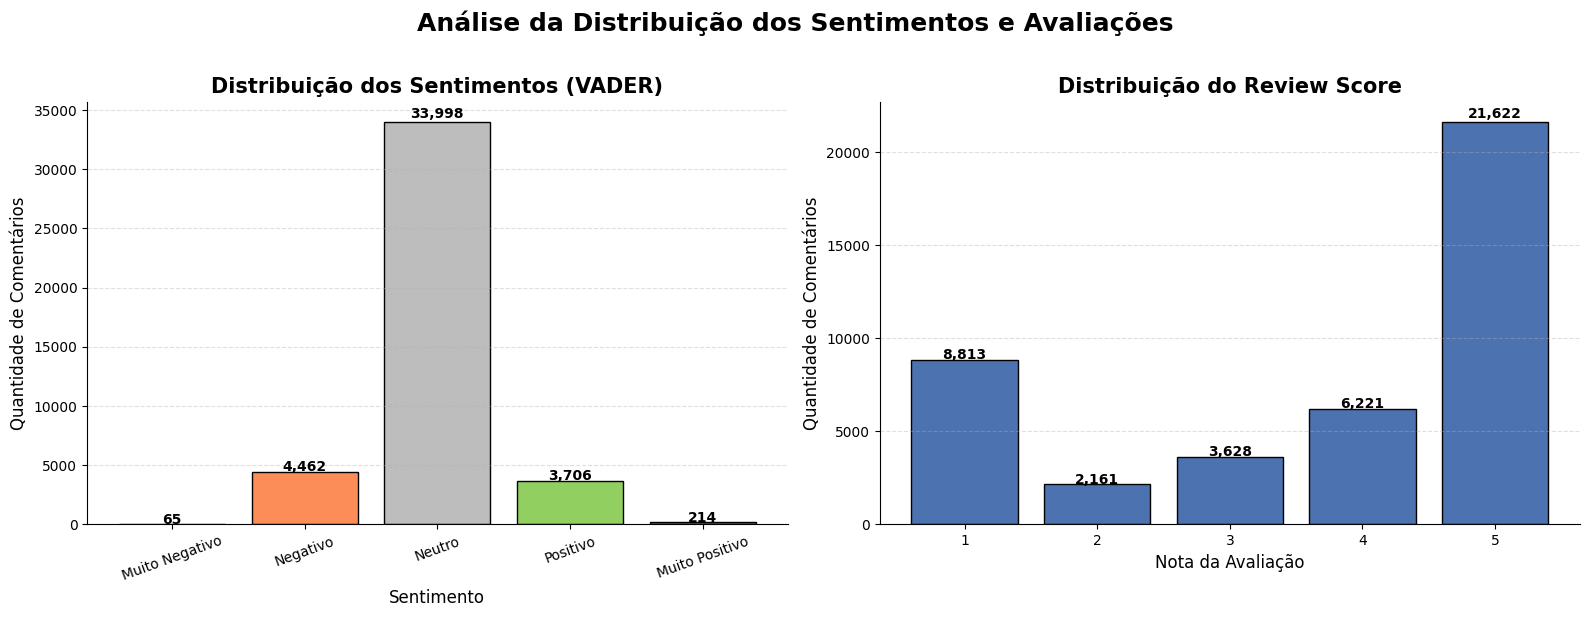

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Contagem dos dados
# ==========================
vader_counts = (
    df_tratado["sentimento_vader"]
    .value_counts()
    .reindex([
        "Muito Negativo",
        "Negativo",
        "Neutro",
        "Positivo",
        "Muito Positivo"
    ])
)

review_counts = (
    df_tratado["review_score"]
    .value_counts()
    .sort_index()
)

# ==========================
# Configuração visual
# ==========================
plt.style.use("default")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Cores
cores_sentimento = [
    "#d73027",  # vermelho forte
    "#fc8d59",  # laranja
    "#bdbdbd",  # cinza
    "#91cf60",  # verde claro
    "#1a9850"   # verde forte
]

cor_review = "#4C72B0"

# ==========================
# Gráfico 1 - Vader
# ==========================
bars1 = ax[0].bar(
    vader_counts.index,
    vader_counts.values,
    color=cores_sentimento,
    edgecolor="black",
    linewidth=1
)

ax[0].set_title(
    "Distribuição dos Sentimentos (VADER)",
    fontsize=15,
    fontweight="bold"
)

ax[0].set_xlabel("Sentimento", fontsize=12)
ax[0].set_ylabel("Quantidade de Comentários", fontsize=12)

ax[0].tick_params(axis="x", rotation=20)

# Grid suave
ax[0].grid(axis="y", linestyle="--", alpha=0.4)

# Remover bordas superiores e direita
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

# Valores acima das barras
for bar in bars1:
    altura = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        altura + (altura * 0.01),
        f"{int(altura):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ==========================
# Gráfico 2 - Review Score
# ==========================
bars2 = ax[1].bar(
    review_counts.index.astype(str),
    review_counts.values,
    color=cor_review,
    edgecolor="black",
    linewidth=1
)

ax[1].set_title(
    "Distribuição do Review Score",
    fontsize=15,
    fontweight="bold"
)

ax[1].set_xlabel("Nota da Avaliação", fontsize=12)
ax[1].set_ylabel("Quantidade de Comentários", fontsize=12)

ax[1].grid(axis="y", linestyle="--", alpha=0.4)

ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

# Valores acima das barras
for bar in bars2:
    altura = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        altura + (altura * 0.01),
        f"{int(altura):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ==========================
# Ajuste final
# ==========================
plt.suptitle(
    "Análise da Distribuição dos Sentimentos e Avaliações",
    fontsize=18,
    fontweight="bold",
    y=1.02
)
# Salvar gráfico
plt.savefig(
    "/content/grafico_sentimentos.png",
    dpi=300,
    bbox_inches="tight"
)

# Fazer download
from google.colab import files
files.download("/content/grafico_sentimentos.png")

plt.tight_layout()
plt.show()

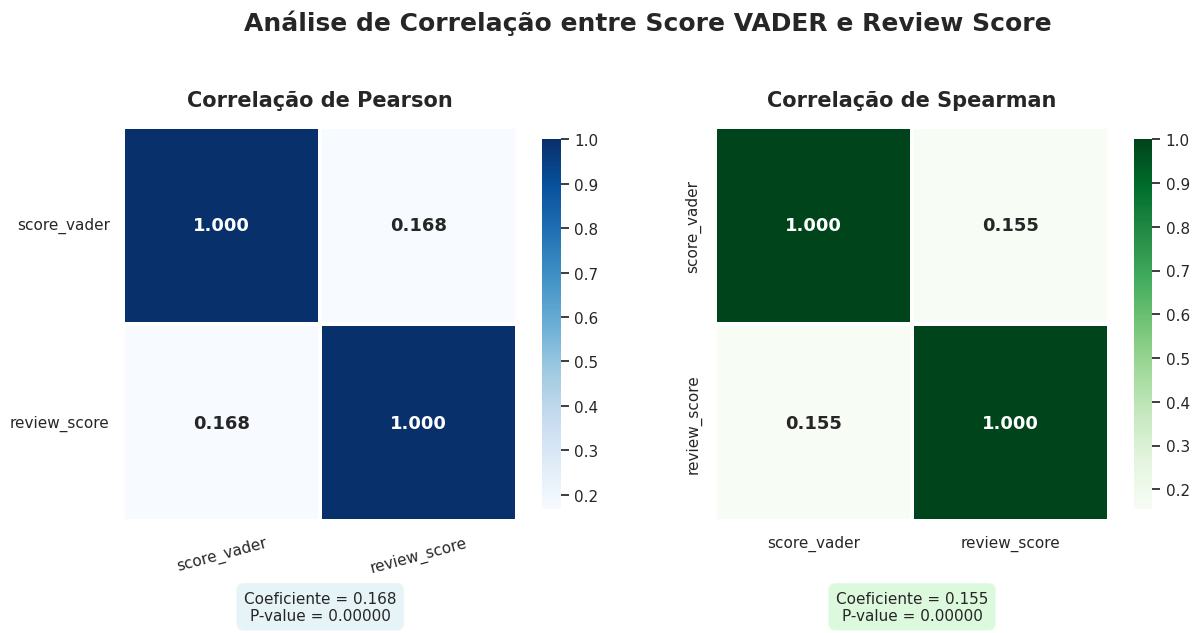

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# 1. Preparar dados
# ==========================
df_corr = df_tratado[
    ["score_vader", "review_score"]
].dropna()

# ==========================
# 2. Correlações
# ==========================
pearson_corr, pearson_p = pearsonr(
    df_corr["score_vader"],
    df_corr["review_score"]
)

spearman_corr, spearman_p = spearmanr(
    df_corr["score_vader"],
    df_corr["review_score"]
)

# Matrizes
corr_pearson = df_corr.corr(method="pearson")
corr_spearman = df_corr.corr(method="spearman")

# ==========================
# 3. Configuração visual
# ==========================
sns.set_theme(style="white")

fig, ax = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

# ==========================
# Pearson
# ==========================
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "size": 13,
        "weight": "bold"
    },
    ax=ax[0]
)

ax[0].set_title(
    "Correlação de Pearson",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax[0].text(
    0.5,
    -0.25,
    f"Coeficiente = {pearson_corr:.3f}\nP-value = {pearson_p:.5f}",
    transform=ax[0].transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="lightblue",
        alpha=0.3
    )
)

ax[0].tick_params(axis="x", rotation=15)
ax[0].tick_params(axis="y", rotation=0)

# ==========================
# Spearman
# ==========================
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".3f",
    cmap="Greens",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "size": 13,
        "weight": "bold"
    },
    ax=ax[1]
)

ax[1].set_title(
    "Correlação de Spearman",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax[1].text(
    0.5,
    -0.25,
    f"Coeficiente = {spearman_corr:.3f}\nP-value = {spearman_p:.5f}",
    transform=ax[1].transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="lightgreen",
        alpha=0.3
    )
)

# ==========================
# Título geral
# ==========================
plt.suptitle(
    "Análise de Correlação entre Score VADER e Review Score",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

# ==========================
# Salvar gráfico
# ==========================
plt.savefig(
    "/content/correlacao_vader_review.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Baixar no computador
# ==========================
from google.colab import files

files.download(
    "/content/correlacao_vader_review.png"
)

plt.tight_layout()
plt.show()

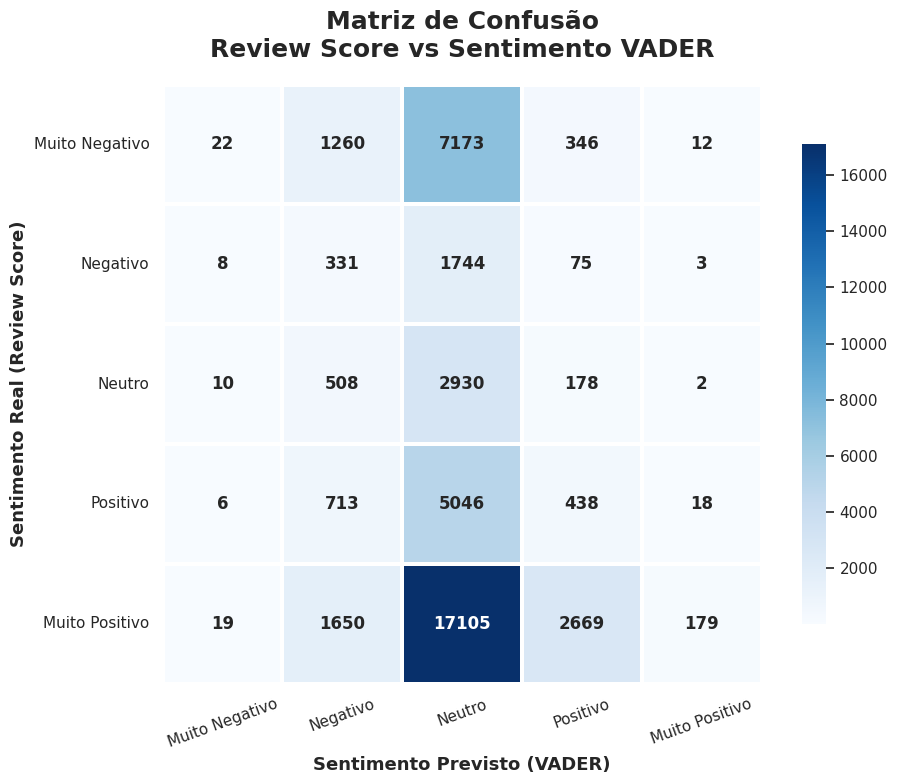

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# ==========================
# 1. Converter review_score
# para categorias
# ==========================

mapa_review = {
    1: "Muito Negativo",
    2: "Negativo",
    3: "Neutro",
    4: "Positivo",
    5: "Muito Positivo"
}

df_tratado["review_sentimento"] = (
    df_tratado["review_score"]
    .map(mapa_review)
)

# ==========================
# 2. Ordem das categorias
# ==========================

ordem = [
    "Muito Negativo",
    "Negativo",
    "Neutro",
    "Positivo",
    "Muito Positivo"
]

# ==========================
# 3. Matriz de confusão
# ==========================

matriz = confusion_matrix(
    df_tratado["review_sentimento"],
    df_tratado["sentimento_vader"],
    labels=ordem
)

matriz_df = pd.DataFrame(
    matriz,
    index=ordem,
    columns=ordem
)

# ==========================
# 4. Plotar Heatmap Bonito
# ==========================

sns.set_theme(style="white")

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

# ==========================
# Títulos e labels
# ==========================

plt.title(
    "Matriz de Confusão\nReview Score vs Sentimento VADER",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Sentimento Previsto (VADER)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Sentimento Real (Review Score)",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=20, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Remover bordas desnecessárias
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# ==========================
# Salvar em alta qualidade
# ==========================

plt.savefig(
    "/content/matriz_confusao_vader.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Download automático
# ==========================

files.download(
    "/content/matriz_confusao_vader.png"
)

Inicio com LeIA

In [ ]:
# instalar biblioteca
!pip install LeIA-br

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 7.1 MB/s eta 0:00:00


In [ ]:
from LeIA import SentimentIntensityAnalyzer

leia = SentimentIntensityAnalyzer()

In [ ]:
# calcular score do LeIA
df_tratado["score_leia"] = (
    df_tratado["comentario_completo"]
    .apply(lambda x: leia.polarity_scores(str(x))["compound"])
)

In [ ]:
# função de classificação
def classificar_leia(score):
    if score <= -0.6:
        return "Muito Negativo"
    elif score <= -0.2:
        return "Negativo"
    elif score < 0.2:
        return "Neutro"
    elif score < 0.6:
        return "Positivo"
    else:
        return "Muito Positivo"

In [ ]:
# aplicar classificação
df_tratado["sentimento_leia"] = (
    df_tratado["score_leia"]
    .apply(classificar_leia)
)

In [ ]:
# visualizar resultados
df_tratado[[

    "review_comment_message",
    "score_leia",
    "sentimento_leia",
    "comentario_completo",
    "review_score"
]].head(20)

,review_comment_message,score_leia,sentimento_leia,comentario_completo,review_score
3,Recebi bem antes do prazo estipulado.,0.2732,Positivo,recebi bem antes prazo estipulado,5
4,Parabéns lojas lannister adorei comprar pela I...,0.9413,Muito Positivo,parabens lojas lannister adorei comprar pela i...,5
9,aparelho eficiente. no site a marca do aparelh...,0.6486,Muito Positivo,recomendo aparelho eficiente no site marca apa...,4
12,"Mas um pouco ,travando...pelo valor ta Boa.",0.7602,Muito Positivo,mas pouco travandopelo valor ta boa,4
15,"Vendedor confiável, produto ok e entrega antes...",0.8979,Muito Positivo,super recomendo vendedor confiavel produto ok ...,5
16,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",0.0000,Neutro,gostaria saber que houve sempre recebi e essa ...,2
19,Péssimo,-0.2960,Negativo,nao chegou meu produto pessimo,1
22,Loja nota 10,0.3612,Positivo,otimo loja nota,5
24,obrigado pela atençao amim dispensada,0.1280,Neutro,obrigado pela atencao amim dispensada,5
27,A compra foi realizada facilmente. A entrega ...,0.6249,Muito Positivo,compra foi realizada facilmente entrega foi ef...,5


In [ ]:
# comparação entre nota e sentimento
pd.crosstab(
    df_tratado["review_score"],
    df_tratado["sentimento_leia"]
)

sentimento_leia,Muito Negativo,Muito Positivo,Negativo,Neutro,Positivo
review_score,,,,,
1,1270,129,4242,2477,695
2,233,94,809,766,259
3,234,318,932,1210,934
4,109,1384,558,1579,2591
5,87,7603,556,4370,9006


In [ ]:
# distribuição dos sentimentos
df_tratado["sentimento_leia"].value_counts()

,count
sentimento_leia,
Positivo,13485
Neutro,10402
Muito Positivo,9528
Negativo,7097
Muito Negativo,1933


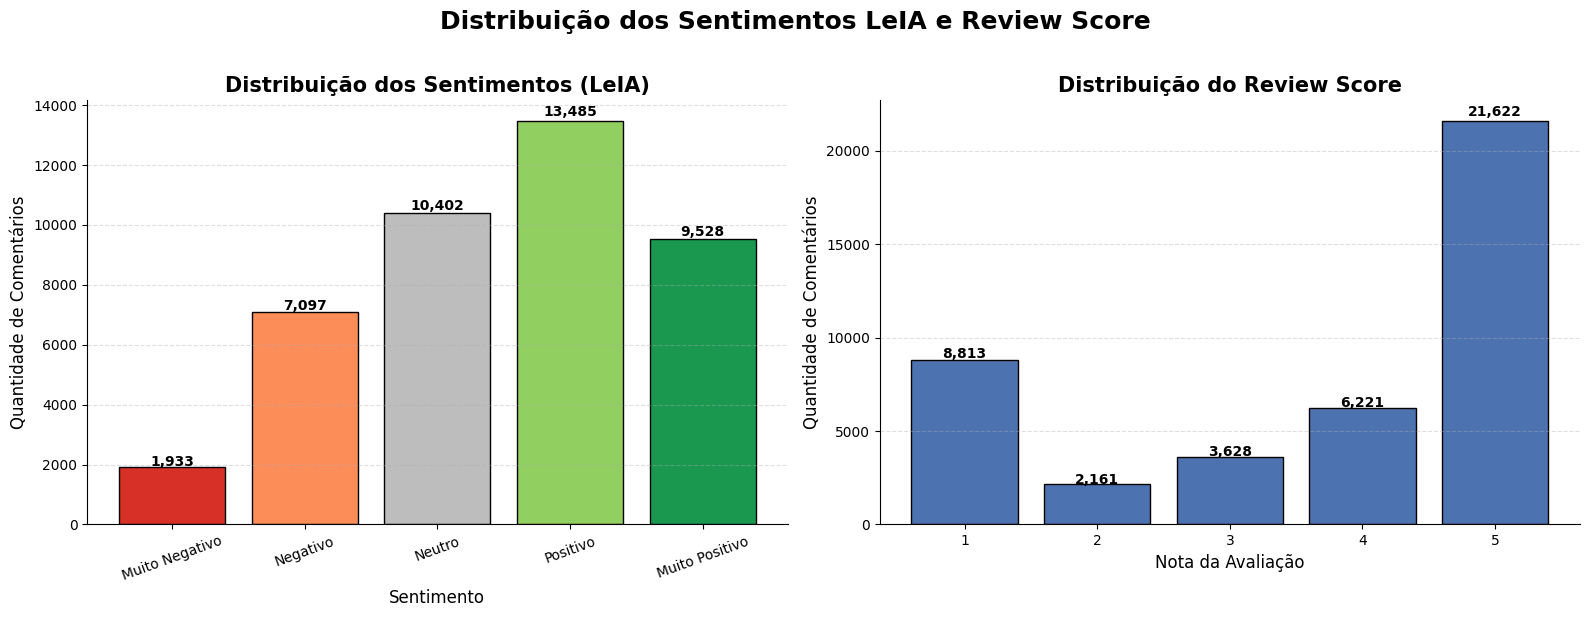

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# 1. Contagem dos sentimentos LeIA
# ==========================

leia_counts = (
    df_tratado["sentimento_leia"]
    .value_counts()
    .reindex([
        "Muito Negativo",
        "Negativo",
        "Neutro",
        "Positivo",
        "Muito Positivo"
    ])
)

# ==========================
# 2. Contagem do review_score
# ==========================

review_counts = (
    df_tratado["review_score"]
    .value_counts()
    .sort_index()
)

# ==========================
# 3. Configuração visual
# ==========================

plt.style.use("default")

fig, ax = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

# Cores
cores_sentimento = [
    "#d73027",  # vermelho forte
    "#fc8d59",  # laranja
    "#bdbdbd",  # cinza
    "#91cf60",  # verde claro
    "#1a9850"   # verde forte
]

cor_review = "#4C72B0"

# ==========================
# Gráfico 1 - LeIA
# ==========================

bars1 = ax[0].bar(
    leia_counts.index,
    leia_counts.values,
    color=cores_sentimento,
    edgecolor="black",
    linewidth=1
)

ax[0].set_title(
    "Distribuição dos Sentimentos (LeIA)",
    fontsize=15,
    fontweight="bold"
)

ax[0].set_xlabel(
    "Sentimento",
    fontsize=12
)

ax[0].set_ylabel(
    "Quantidade de Comentários",
    fontsize=12
)

ax[0].tick_params(
    axis="x",
    rotation=20
)

# Grid suave
ax[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Remover bordas
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

# Valores acima das barras
for bar in bars1:
    altura = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        altura + (altura * 0.01),
        f"{int(altura):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ==========================
# Gráfico 2 - Review Score
# ==========================

bars2 = ax[1].bar(
    review_counts.index.astype(str),
    review_counts.values,
    color=cor_review,
    edgecolor="black",
    linewidth=1
)

ax[1].set_title(
    "Distribuição do Review Score",
    fontsize=15,
    fontweight="bold"
)

ax[1].set_xlabel(
    "Nota da Avaliação",
    fontsize=12
)

ax[1].set_ylabel(
    "Quantidade de Comentários",
    fontsize=12
)

ax[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

# Valores acima das barras
for bar in bars2:
    altura = bar.get_height()
    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        altura + (altura * 0.01),
        f"{int(altura):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ==========================
# Título geral
# ==========================

plt.suptitle(
    "Distribuição dos Sentimentos LeIA e Review Score",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# ==========================
# Salvar gráfico
# ==========================

plt.savefig(
    "/content/distribuicao_leia_review.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Download automático
# ==========================

files.download(
    "/content/distribuicao_leia_review.png"
)

📌 Correlação de Pearson (LeIA)
Coeficiente: 0.6239
P-valor: 0.0000e+00


📌 Correlação de Spearman (LeIA)
Coeficiente: 0.5849
P-valor: 0.0000e+00


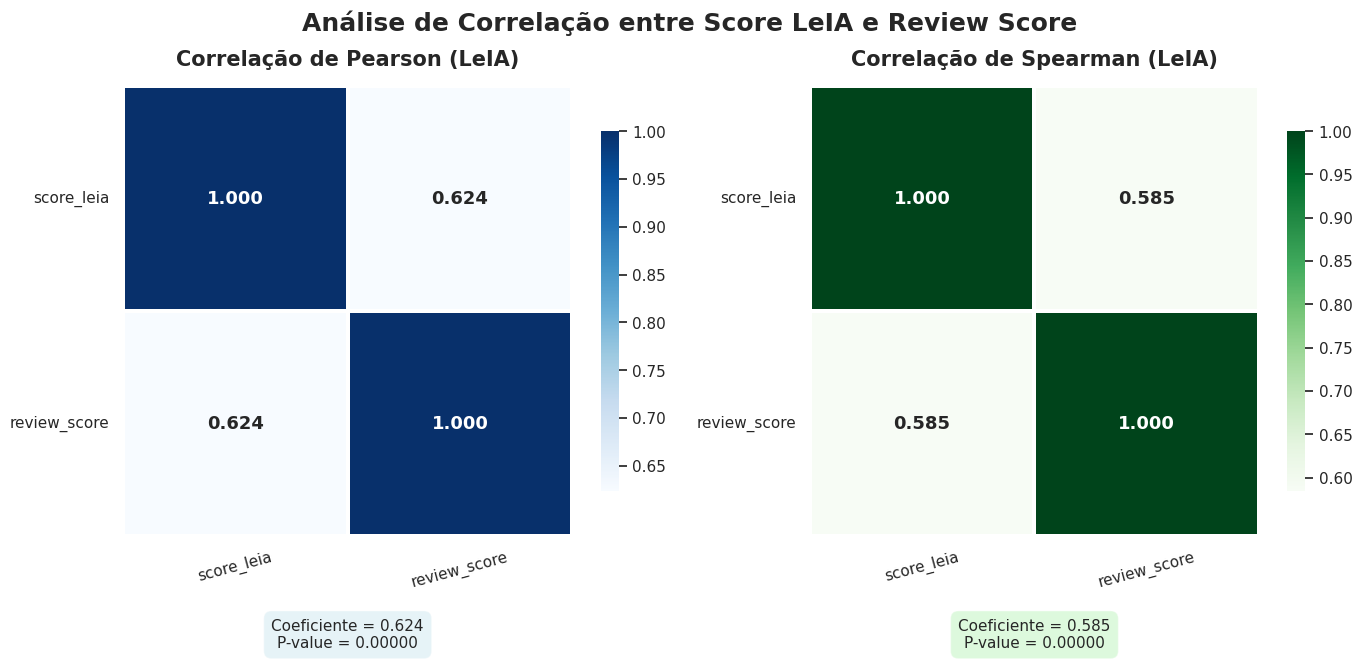

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# 1. Preparar dados
# ==========================

df_corr = df_tratado[
    ["score_leia", "review_score"]
].dropna()

# ==========================
# 2. Calcular correlações
# ==========================

# Pearson
pearson_corr, pearson_p = pearsonr(
    df_corr["score_leia"],
    df_corr["review_score"]
)

# Spearman
spearman_corr, spearman_p = spearmanr(
    df_corr["score_leia"],
    df_corr["review_score"]
)

# ==========================
# 3. Mostrar resultados
# ==========================

print("📌 Correlação de Pearson (LeIA)")
print(f"Coeficiente: {pearson_corr:.4f}")
print(f"P-valor: {pearson_p:.4e}")

print("\n" + "=" * 50 + "\n")

print("📌 Correlação de Spearman (LeIA)")
print(f"Coeficiente: {spearman_corr:.4f}")
print(f"P-valor: {spearman_p:.4e}")

# ==========================
# 4. Matrizes de correlação
# ==========================

corr_pearson = df_corr.corr(method="pearson")
corr_spearman = df_corr.corr(method="spearman")

# ==========================
# 5. Configuração visual
# ==========================

sns.set_theme(style="white")

fig, ax = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

# ==========================
# Pearson
# ==========================

sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "size": 13,
        "weight": "bold"
    },
    ax=ax[0]
)

ax[0].set_title(
    "Correlação de Pearson (LeIA)",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax[0].text(
    0.5,
    -0.25,
    f"Coeficiente = {pearson_corr:.3f}\nP-value = {pearson_p:.5f}",
    transform=ax[0].transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="lightblue",
        alpha=0.3
    )
)

ax[0].tick_params(axis="x", rotation=15)
ax[0].tick_params(axis="y", rotation=0)

# ==========================
# Spearman
# ==========================

sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".3f",
    cmap="Greens",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "size": 13,
        "weight": "bold"
    },
    ax=ax[1]
)

ax[1].set_title(
    "Correlação de Spearman (LeIA)",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax[1].text(
    0.5,
    -0.25,
    f"Coeficiente = {spearman_corr:.3f}\nP-value = {spearman_p:.5f}",
    transform=ax[1].transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="lightgreen",
        alpha=0.3
    )
)

ax[1].tick_params(axis="x", rotation=15)
ax[1].tick_params(axis="y", rotation=0)

# ==========================
# Título geral
# ==========================

plt.suptitle(
    "Análise de Correlação entre Score LeIA e Review Score",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# ==========================
# Salvar em alta qualidade
# ==========================

plt.savefig(
    "/content/correlacao_leia_review.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Download automático
# ==========================

files.download(
    "/content/correlacao_leia_review.png"
)

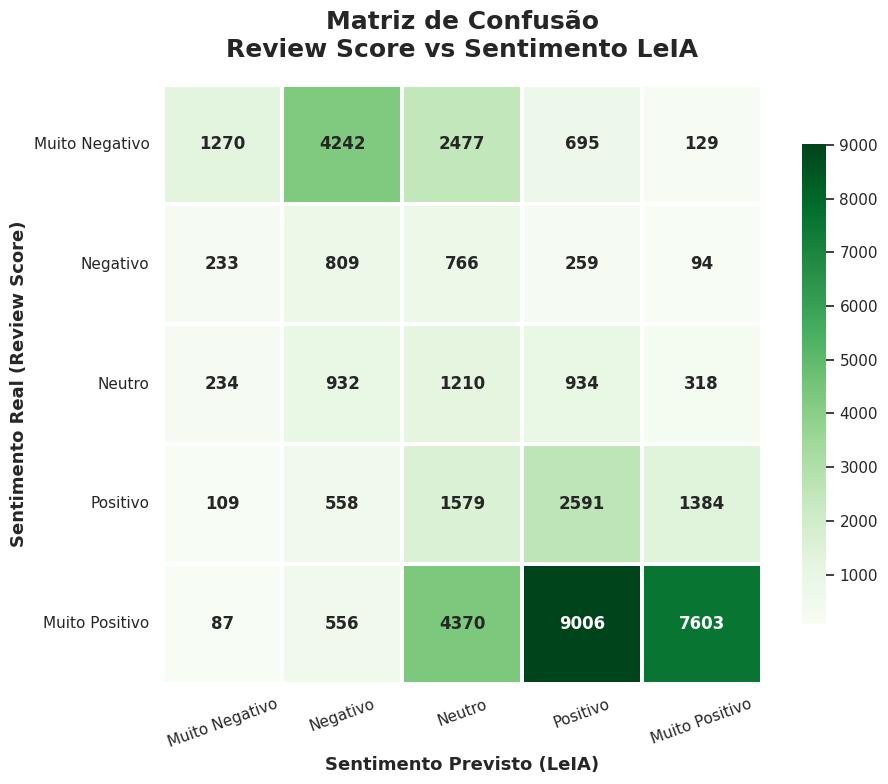

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# ==========================
# 1. Converter review_score
# para categorias de sentimento
# ==========================

mapa_review = {
    1: "Muito Negativo",
    2: "Negativo",
    3: "Neutro",
    4: "Positivo",
    5: "Muito Positivo"
}

df_tratado["review_sentimento"] = (
    df_tratado["review_score"]
    .map(mapa_review)
)

# ==========================
# 2. Ordem das categorias
# ==========================

ordem = [
    "Muito Negativo",
    "Negativo",
    "Neutro",
    "Positivo",
    "Muito Positivo"
]

# ==========================
# 3. Criar matriz de confusão
# ==========================

matriz = confusion_matrix(
    df_tratado["review_sentimento"],
    df_tratado["sentimento_leia"],
    labels=ordem
)

# Converter para DataFrame
matriz_df = pd.DataFrame(
    matriz,
    index=ordem,
    columns=ordem
)

# ==========================
# 4. Configuração visual
# ==========================

sns.set_theme(style="white")

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_df,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

# ==========================
# Títulos e labels
# ==========================

plt.title(
    "Matriz de Confusão\nReview Score vs Sentimento LeIA",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Sentimento Previsto (LeIA)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Sentimento Real (Review Score)",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(
    rotation=20,
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)

# Remover bordas externas
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# ==========================
# Salvar em alta qualidade
# ==========================

plt.savefig(
    "/content/matriz_confusao_leia.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Download automático
# ==========================

files.download(
    "/content/matriz_confusao_leia.png"
)

Inicio com Transformers

In [ ]:
# instalar biblioteca
!pip install transformers

In [ ]:
!pip install torch transformers

In [ ]:
from transformers import pipeline
import torch

In [ ]:
#!pip uninstall transformers -y
#!pip install transformers==4.41.2

In [ ]:
# carregar modelo pré-treinado
nlp_transformers = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
def analisar_roberta(texto):

    try:

        resultado = nlp_transformers(
            str(texto)
        )[0]

        return pd.Series({

            "sentimento_roberta": resultado["label"],
            "score_roberta": resultado["score"]

        })

    except:

        return pd.Series({

            "sentimento_roberta": None,
            "score_roberta": None

        })

In [ ]:
df_tratado[
    ["sentimento_roberta",
     "score_transformer"]
] = df_tratado[
    "comentario_completo"
].apply(analisar_roberta)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
mapa = {

    "positive":"Positivo",
    "negative":"Negativo",
    "neutral":"Neutro"

}

df_tratado["sentimento_roberta"] = (

    df_tratado[
        "sentimento_roberta"
    ].map(mapa)

)

In [ ]:
df_tratado[
[
    "review_score",
    "review_comment_message",
    "comentario_completo",
    "sentimento_roberta",
    "score_transformer"
]
].head(50)

,review_score,review_comment_message,comentario_completo,sentimento_roberta,score_transformer
3,5,Recebi bem antes do prazo estipulado.,recebi bem antes prazo estipulado,Neutro,0.855670
4,5,Parabéns lojas lannister adorei comprar pela I...,parabens lojas lannister adorei comprar pela i...,Neutro,0.793598
9,4,aparelho eficiente. no site a marca do aparelh...,recomendo aparelho eficiente no site marca apa...,Neutro,0.825635
12,4,"Mas um pouco ,travando...pelo valor ta Boa.",mas pouco travandopelo valor ta boa,Neutro,0.804880
15,5,"Vendedor confiável, produto ok e entrega antes...",super recomendo vendedor confiavel produto ok ...,Neutro,0.715267
16,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",gostaria saber que houve sempre recebi e essa ...,Neutro,0.803975
19,1,Péssimo,nao chegou meu produto pessimo,Neutro,0.825489
22,5,Loja nota 10,otimo loja nota,Neutro,0.774490
24,5,obrigado pela atençao amim dispensada,obrigado pela atencao amim dispensada,Neutro,0.774866
27,5,A compra foi realizada facilmente. A entrega ...,compra foi realizada facilmente entrega foi ef...,Neutro,0.825430


In [ ]:
# comparação entre nota e sentimento
pd.crosstab(
    df_tratado["review_score"],
    df_tratado["sentimento_roberta"]
)

sentimento_roberta,Negativo,Neutro,Positivo
review_score,,,
1,4,8805,4
2,0,2158,3
3,0,3623,5
4,0,6201,20
5,0,21342,280


In [ ]:
# atualizar SOMENTE a tabela avaliacoes
df["avaliacoes"] = df_tratado.copy()

# caminho do parquet no Google Drive
caminho_avaliacoes = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "projeto integrador /parquet/avaliacoes.parquet"
)

# salvar somente o parquet de avaliacoes
df["avaliacoes"].to_parquet(
    caminho_avaliacoes,
    index=False,
    engine="pyarrow",
    compression="snappy"
)

print("✅ avaliacoes atualizada!")

✅ avaliacoes atualizada!


In [ ]:
display(df["avaliacoes"].head())

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,comentario_completo,score_vader,sentimento_vader,review_sentimento,score_leia,sentimento_leia,sentimento_roberta,score_transformer
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,recebi bem antes prazo estipulado,0.0000,Neutro,Muito Positivo,0.2732,Positivo,Neutro,0.855670
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,parabens lojas lannister adorei comprar pela i...,0.0000,Neutro,Muito Positivo,0.9413,Muito Positivo,Neutro,0.793598
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22,2018-05-23 16:45:47,recomendo aparelho eficiente no site marca apa...,-0.2960,Negativo,Positivo,0.6486,Muito Positivo,Neutro,0.825635
12,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,,"Mas um pouco ,travando...pelo valor ta Boa.",2018-02-16,2018-02-20 10:52:22,mas pouco travandopelo valor ta boa,0.0000,Neutro,Positivo,0.7602,Muito Positivo,Neutro,0.804880
15,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,Super recomendo,"Vendedor confiável, produto ok e entrega antes...",2018-05-23,2018-05-24 03:00:01,super recomendo vendedor confiavel produto ok ...,0.7269,Muito Positivo,Muito Positivo,0.8979,Muito Positivo,Neutro,0.715267


PySentimento - Transforms






In [ ]:
!pip install pysentimiento

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.1 MB/s eta 0:00:00


In [ ]:
from pysentimiento import create_analyzer
import pandas as pd

In [ ]:
# carregar modelo PT-BR
analisador = create_analyzer(
    task="sentiment",
    lang="pt"
)

config.json:   0%|          | 0.00/952 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/562 [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/799k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

In [ ]:
def analisar_pysentimento(texto):

    try:

        resultado = analisador.predict(
            str(texto)
        )

        label = resultado.output
        score = max(
            resultado.probas.values()
        )

        return pd.Series({

            "sentimento_base": label,
            "score_pysentimento": score

        })

    except:

        return pd.Series({

            "sentimento_base": None,
            "score_pysentimento": None

        })

In [ ]:
# aplicar modelo
df_tratado[
    [
        "sentimento_base",
        "score_pysentimento"
    ]
] = df_tratado[
    "comentario_completo"
].apply(
    analisar_pysentimento
)

In [ ]:
def classificar_sentimento(sentimento, score):

    if pd.isna(sentimento):
        return None, None

    # NEGATIVO
    if sentimento == "NEG":

        # Nota 2
        if score <= 0.75:
            return "Negativo", 2

        # Nota 1
        return "Muito Negativo", 1

    # POSITIVO
    elif sentimento == "POS":

        # Nota 5
        if score >= 0.75:
            return "Muito Positivo", 5

        # Nota 4
        return "Positivo", 4

    # NEUTRO
    return "Neutro", 3

In [ ]:
df_tratado[["classe_sentimento", "nota_prevista"]] = (
    df_tratado.apply(
        lambda row: pd.Series(
            classificar_sentimento(
                row["sentimento_base"],
                row["score_pysentimento"]
            )
        ),
        axis=1
    )
)

In [ ]:
df_tratado[
    "sentimento_pysentimento"
] = df_tratado.apply(

    lambda x:
        classificar_sentimento(

            x["sentimento_base"],
            x["score_pysentimento"]

        ),

    axis=1
)

In [ ]:
df_tratado["classe_sentimento"].value_counts()

,count
classe_sentimento,
Muito Positivo,19661
Neutro,13081
Muito Negativo,5446
Negativo,2675
Positivo,1582


In [ ]:
pd.crosstab(
    df_tratado["review_score"],
    [
        df_tratado["nota_prevista"],
        df_tratado["classe_sentimento"]
    ]
)

nota_prevista,1,2,3,4,5
classe_sentimento,Muito Negativo,Negativo,Neutro,Positivo,Muito Positivo
review_score,,,,,
1,3528,1484,3701,33,67
2,684,331,1044,23,79
3,707,426,1781,141,573
4,351,279,2288,367,2936
5,176,155,4267,1018,16006


In [ ]:
pd.crosstab(
    df_tratado["review_score"],
    [
        df_tratado["classe_sentimento"]
    ]
)

classe_sentimento,Muito Negativo,Muito Positivo,Negativo,Neutro,Positivo
review_score,,,,,
1,3528,67,1484,3701,33
2,684,79,331,1044,23
3,707,573,426,1781,141
4,351,2936,279,2288,367
5,176,16006,155,4267,1018


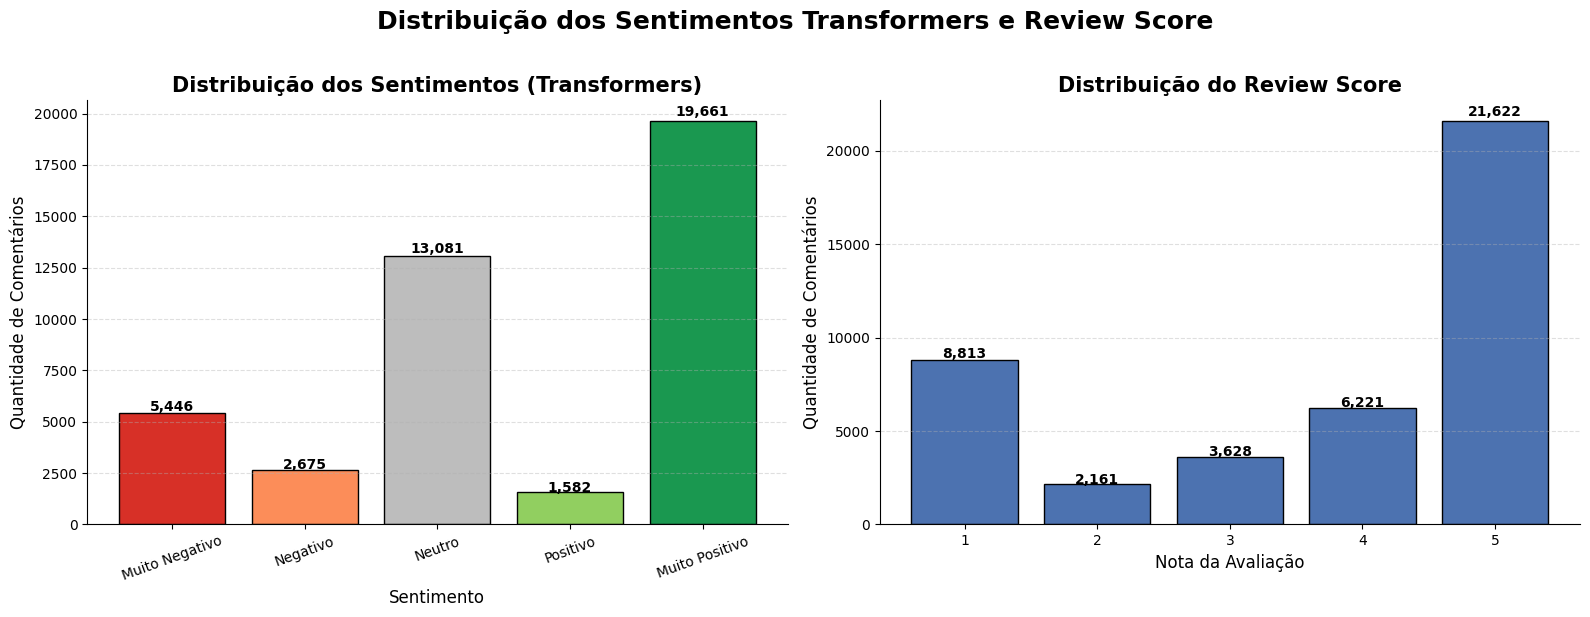

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# 1. Contagem dos sentimentos
# ==========================

pysentimento_counts = (
    df_tratado["classe_sentimento"]
    .value_counts()
    .reindex([
        "Muito Negativo",
        "Negativo",
        "Neutro",
        "Positivo",
        "Muito Positivo"
    ])
)

# ==========================
# 2. Contagem review_score
# ==========================

review_counts = (
    df_tratado["review_score"]
    .value_counts()
    .sort_index()
)

# ==========================
# 3. Configuração visual
# ==========================

plt.style.use("default")

fig, ax = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

# Cores dos sentimentos
cores_sentimento = [
    "#d73027",  # vermelho forte
    "#fc8d59",  # laranja
    "#bdbdbd",  # cinza
    "#91cf60",  # verde claro
    "#1a9850"   # verde forte
]

cor_review = "#4C72B0"

# ==========================
# Gráfico 1 - Transformers
# ==========================

bars1 = ax[0].bar(
    pysentimento_counts.index,
    pysentimento_counts.values,
    color=cores_sentimento,
    edgecolor="black",
    linewidth=1
)

ax[0].set_title(
    "Distribuição dos Sentimentos (Transformers)",
    fontsize=15,
    fontweight="bold"
)

ax[0].set_xlabel(
    "Sentimento",
    fontsize=12
)

ax[0].set_ylabel(
    "Quantidade de Comentários",
    fontsize=12
)

ax[0].tick_params(
    axis="x",
    rotation=20
)

# Grid suave
ax[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Remover bordas superiores
ax[0].spines["top"].set_visible(False)
ax[0].spines["right"].set_visible(False)

# Valores acima das barras
for bar in bars1:
    altura = bar.get_height()

    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        altura + (altura * 0.01),
        f"{int(altura):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ==========================
# Gráfico 2 - Review Score
# ==========================

bars2 = ax[1].bar(
    review_counts.index.astype(str),
    review_counts.values,
    color=cor_review,
    edgecolor="black",
    linewidth=1
)

ax[1].set_title(
    "Distribuição do Review Score",
    fontsize=15,
    fontweight="bold"
)

ax[1].set_xlabel(
    "Nota da Avaliação",
    fontsize=12
)

ax[1].set_ylabel(
    "Quantidade de Comentários",
    fontsize=12
)

ax[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax[1].spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)

# Valores acima das barras
for bar in bars2:
    altura = bar.get_height()

    ax[1].text(
        bar.get_x() + bar.get_width()/2,
        altura + (altura * 0.01),
        f"{int(altura):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ==========================
# Título geral
# ==========================

plt.suptitle(
    "Distribuição dos Sentimentos Transformers e Review Score",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# ==========================
# Salvar gráfico
# ==========================

plt.savefig(
    "/content/distribuicao_transformers_review.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Download automático
# ==========================

files.download(
    "/content/distribuicao_transformers_review.png"
)

📌 Correlação de Pearson (PySentimento)
Coeficiente: 0.7117
P-valor: 0.0000e+00


📌 Correlação de Spearman (PySentimento)
Coeficiente: 0.7013
P-valor: 0.0000e+00


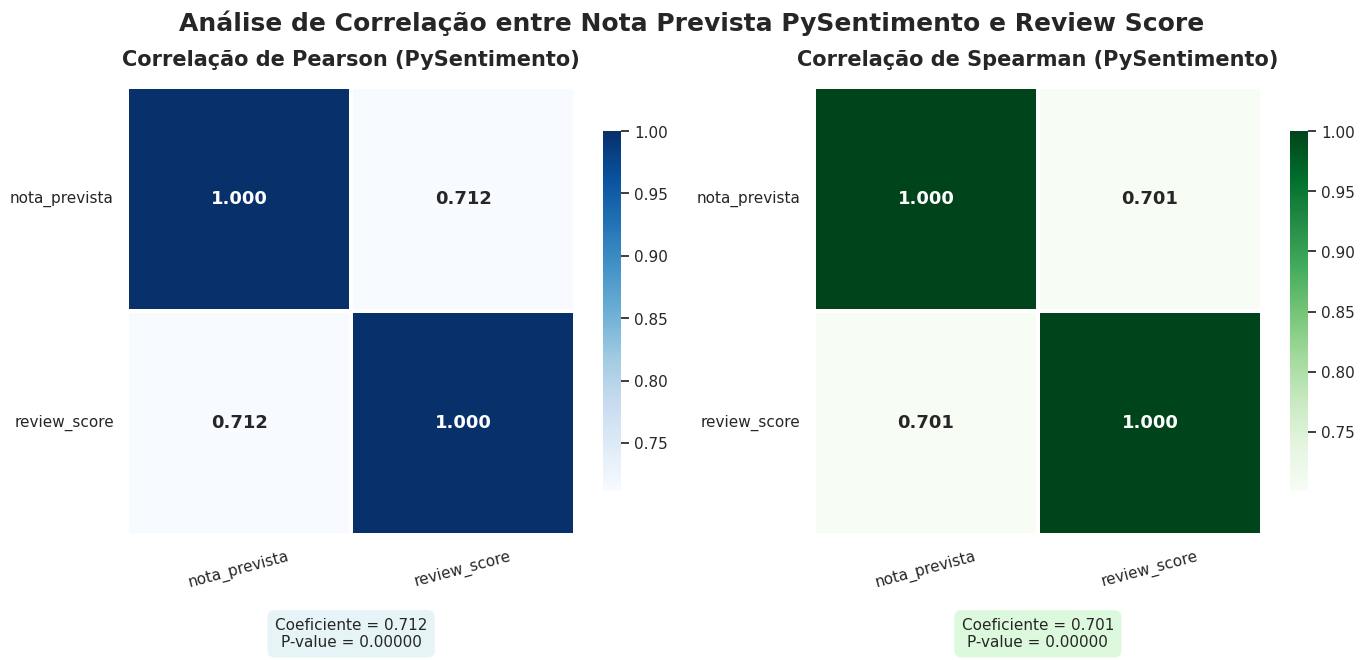

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# 1. Preparar dados
# ==========================

df_corr = df_tratado[
    ["nota_prevista", "review_score"]
].dropna()

# Garantir inteiro
df_corr["nota_prevista"] = (
    df_corr["nota_prevista"]
    .astype(int)
)

df_corr["review_score"] = (
    df_corr["review_score"]
    .astype(int)
)

# ==========================
# 2. Calcular correlações
# ==========================

# Pearson
pearson_corr, pearson_p = pearsonr(
    df_corr["nota_prevista"],
    df_corr["review_score"]
)

# Spearman
spearman_corr, spearman_p = spearmanr(
    df_corr["nota_prevista"],
    df_corr["review_score"]
)

# ==========================
# 3. Mostrar resultados
# ==========================

print("📌 Correlação de Pearson (PySentimento)")
print(f"Coeficiente: {pearson_corr:.4f}")
print(f"P-valor: {pearson_p:.4e}")

print("\n" + "=" * 50 + "\n")

print("📌 Correlação de Spearman (PySentimento)")
print(f"Coeficiente: {spearman_corr:.4f}")
print(f"P-valor: {spearman_p:.4e}")

# ==========================
# 4. Matrizes de correlação
# ==========================

corr_pearson = df_corr.corr(method="pearson")
corr_spearman = df_corr.corr(method="spearman")

# ==========================
# 5. Configuração visual
# ==========================

sns.set_theme(style="white")

fig, ax = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

# ==========================
# Pearson
# ==========================

sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "size": 13,
        "weight": "bold"
    },
    ax=ax[0]
)

ax[0].set_title(
    "Correlação de Pearson (PySentimento)",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax[0].text(
    0.5,
    -0.25,
    f"Coeficiente = {pearson_corr:.3f}\nP-value = {pearson_p:.5f}",
    transform=ax[0].transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="lightblue",
        alpha=0.3
    )
)

ax[0].tick_params(axis="x", rotation=15)
ax[0].tick_params(axis="y", rotation=0)

# ==========================
# Spearman
# ==========================

sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".3f",
    cmap="Greens",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "size": 13,
        "weight": "bold"
    },
    ax=ax[1]
)

ax[1].set_title(
    "Correlação de Spearman (PySentimento)",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax[1].text(
    0.5,
    -0.25,
    f"Coeficiente = {spearman_corr:.3f}\nP-value = {spearman_p:.5f}",
    transform=ax[1].transAxes,
    ha="center",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="lightgreen",
        alpha=0.3
    )
)

ax[1].tick_params(axis="x", rotation=15)
ax[1].tick_params(axis="y", rotation=0)

# ==========================
# Título geral
# ==========================

plt.suptitle(
    "Análise de Correlação entre Nota Prevista PySentimento e Review Score",
    fontsize=18,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# ==========================
# Salvar gráfico
# ==========================

plt.savefig(
    "/content/correlacao_pysentimento_review.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Download automático
# ==========================

files.download(
    "/content/correlacao_pysentimento_review.png"
)

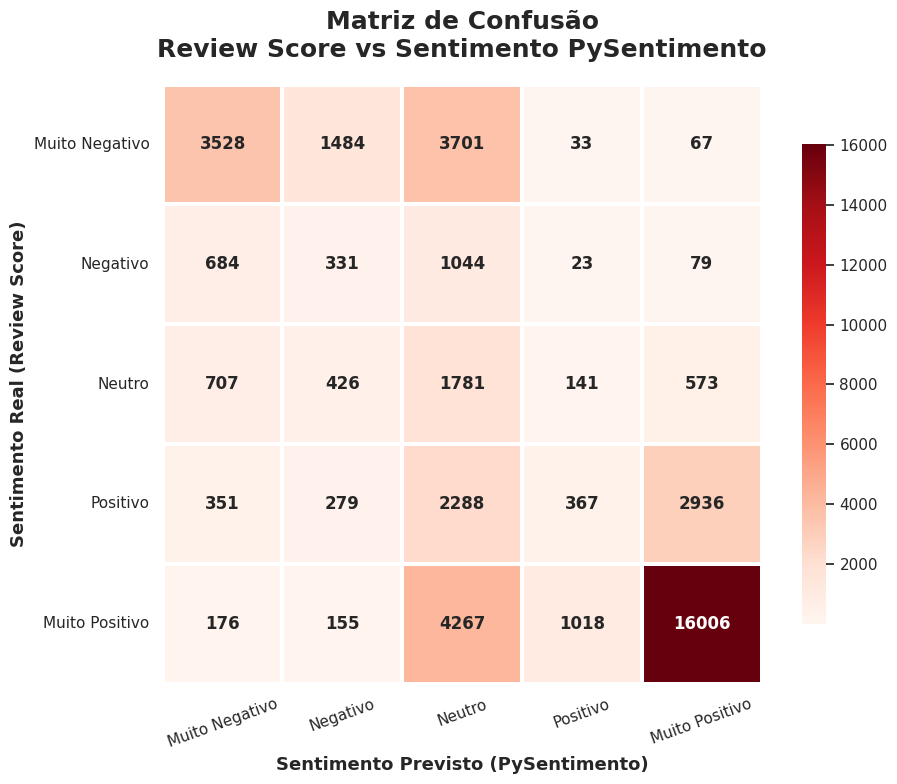

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# ==========================
# 1. Converter review_score
# para categorias de sentimento
# ==========================

mapa_review = {
    1: "Muito Negativo",
    2: "Negativo",
    3: "Neutro",
    4: "Positivo",
    5: "Muito Positivo"
}

df_tratado["review_sentimento"] = (
    df_tratado["review_score"]
    .map(mapa_review)
)

# ==========================
# 2. Ordem das categorias
# ==========================

ordem = [
    "Muito Negativo",
    "Negativo",
    "Neutro",
    "Positivo",
    "Muito Positivo"
]

# ==========================
# 3. Matriz de confusão
# ==========================

matriz = confusion_matrix(
    df_tratado["review_sentimento"],
    df_tratado["classe_sentimento"],
    labels=ordem
)

# Transformar em DataFrame
matriz_df = pd.DataFrame(
    matriz,
    index=ordem,
    columns=ordem
)

# ==========================
# 4. Configuração visual
# ==========================

sns.set_theme(style="white")

plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    matriz_df,
    annot=True,
    fmt="d",
    cmap="Reds",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

# ==========================
# Títulos e labels
# ==========================

plt.title(
    "Matriz de Confusão\nReview Score vs Sentimento PySentimento",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Sentimento Previsto (PySentimento)",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Sentimento Real (Review Score)",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(
    rotation=20,
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)

# Remover bordas externas
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# ==========================
# Salvar em alta qualidade
# ==========================

plt.savefig(
    "/content/matriz_confusao_pysentimento.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Download automático
# ==========================

files.download(
    "/content/matriz_confusao_pysentimento.png"
)

# Gráficos

Comparação das 3 análises de sentimento

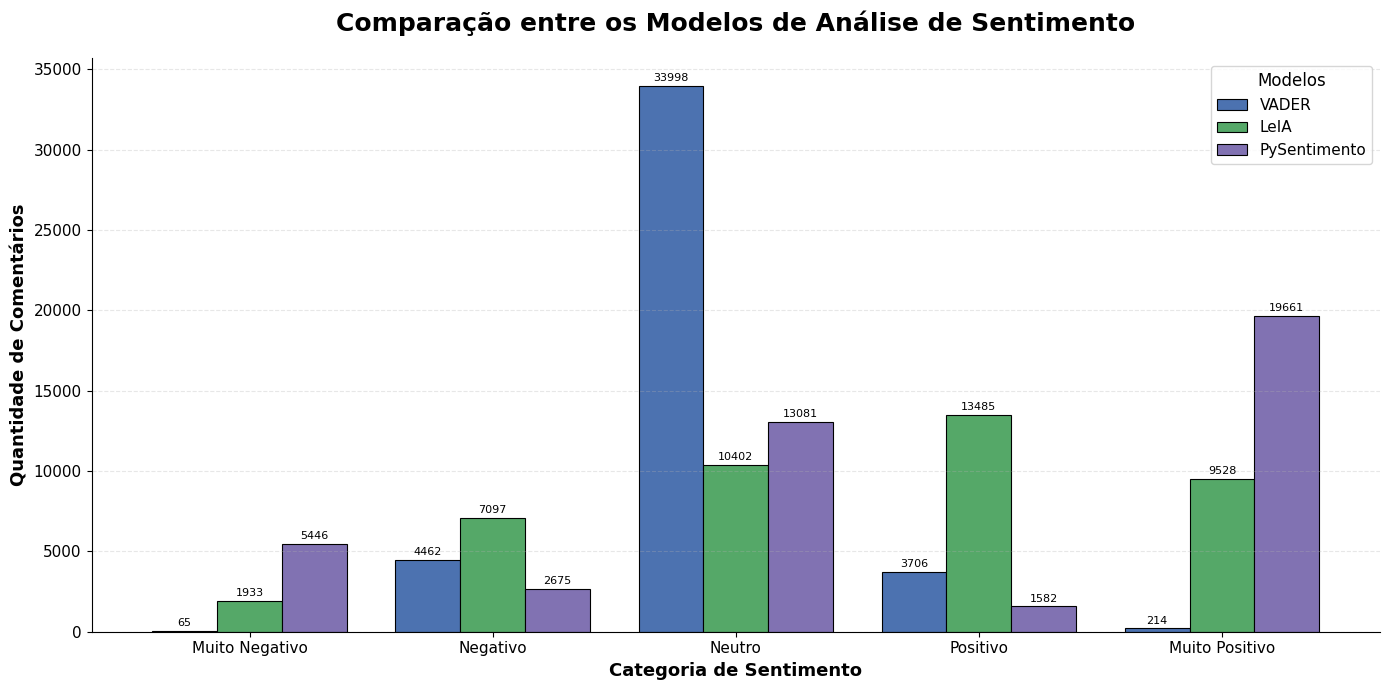

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from google.colab import files

# ==========================
# 1. Contagem dos sentimentos
# ==========================

vader_counts = df_tratado["sentimento_vader"].value_counts()

leia_counts = df_tratado["sentimento_leia"].value_counts()

pysentimento_counts = (
    df_tratado["classe_sentimento"]
    .value_counts()
)

# ==========================
# 2. Criar DataFrame
# ==========================

comparacao = pd.DataFrame({
    "VADER": vader_counts,
    "LeIA": leia_counts,
    "PySentimento": pysentimento_counts
}).fillna(0)

# Ordenar sentimentos
ordem = [
    "Muito Negativo",
    "Negativo",
    "Neutro",
    "Positivo",
    "Muito Positivo"
]

comparacao = comparacao.loc[ordem]

# ==========================
# 3. Configuração visual
# ==========================

plt.style.use("default")

fig, ax = plt.subplots(
    figsize=(14, 7)
)

# Cores dos modelos
cores = [
    "#4C72B0",  # azul - VADER
    "#55A868",  # verde - LeIA
    "#8172B2"   # roxo - PySentimento
]

# Criar gráfico
comparacao.plot(
    kind="bar",
    ax=ax,
    color=cores,
    edgecolor="black",
    linewidth=0.8,
    width=0.8
)

# ==========================
# Estilo do gráfico
# ==========================

ax.set_title(
    "Comparação entre os Modelos de Análise de Sentimento",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Categoria de Sentimento",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Quantidade de Comentários",
    fontsize=13,
    fontweight="bold"
)

ax.tick_params(
    axis="x",
    rotation=0,
    labelsize=11
)

ax.tick_params(
    axis="y",
    labelsize=11
)

# Grid suave
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Remover bordas superiores e direita
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ==========================
# Valores nas barras
# ==========================

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=8,
        padding=2
    )

# ==========================
# Legenda
# ==========================

plt.legend(
    title="Modelos",
    fontsize=11,
    title_fontsize=12,
    loc="upper right"
)

plt.tight_layout()

# ==========================
# Salvar gráfico
# ==========================

plt.savefig(
    "/content/comparacao_modelos_sentimento.png",
    dpi=300,
    bbox_inches="tight"
)

# Mostrar gráfico
plt.show()

# ==========================
# Download automático
# ==========================

files.download(
    "/content/comparacao_modelos_sentimento.png"
)